In [ ]:
!pip install scikit-learn joblib

In [ ]:
from scipy.ndimage import gaussian_filter1d

In [ ]:
import os
import glob
import zipfile

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from sklearn.preprocessing import StandardScaler

import joblib

from google.colab import files

In [ ]:
uploaded = files.upload()

Saving imu_dataset.zip to imu_dataset.zip


In [ ]:
with zipfile.ZipFile("imu_dataset.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset extracted.")

Dataset extracted.


In [ ]:
FEATURE_COLUMNS = [
    "ax",
    "ay",
    "az",
    "gx",
    "gy",
    "gz",
    "mx",
    "my",
    "mz"
]

In [ ]:
def extract_features(data):

    features = []

    # -----------------------------
    # Per-axis features
    # -----------------------------

    for i in range(data.shape[1]):

        signal = gaussian_filter1d(
            data[:, i],
            sigma=1
        )

        # Basic stats
        features.append(np.mean(signal))
        features.append(np.std(signal))
        features.append(np.min(signal))
        features.append(np.max(signal))
        features.append(np.median(signal))

        # Shape stats
        features.append(skew(signal))
        features.append(kurtosis(signal))

        # Energy
        features.append(np.sum(signal ** 2))

        # Percentiles
        features.append(np.percentile(signal, 25))
        features.append(np.percentile(signal, 75))

        # Signal dynamics
        diff_signal = np.diff(signal)

        features.append(np.mean(np.abs(diff_signal)))
        features.append(np.std(diff_signal))

        # FFT frequency features
        fft_vals = np.abs(np.fft.rfft(signal))

        features.append(np.mean(fft_vals))
        features.append(np.std(fft_vals))
        features.append(np.max(fft_vals))

    # -----------------------------
    # Magnitude features
    # -----------------------------

    acc_mag = np.linalg.norm(data[:, 0:3], axis=1)

    gyro_mag = np.linalg.norm(data[:, 3:6], axis=1)

    mag_mag = np.linalg.norm(data[:, 6:9], axis=1)

    for signal in [acc_mag, gyro_mag, mag_mag]:

        features.append(np.mean(signal))
        features.append(np.std(signal))
        features.append(np.min(signal))
        features.append(np.max(signal))

        features.append(np.median(signal))

        features.append(np.sum(signal ** 2))

        features.append(skew(signal))
        features.append(kurtosis(signal))

    # --------------------------------
    # Correlation features
    # --------------------------------

    corr_matrix = np.corrcoef(data.T)

    upper = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]

    features.extend(upper)

    return np.array(features)

In [ ]:
X = []
y = []

dataset_root = "dataset/imu_dataset"

for label in sorted(os.listdir(dataset_root)):

    label_dir = os.path.join(dataset_root, label)

    if not os.path.isdir(label_dir):
        continue

    csv_files = glob.glob(
        os.path.join(label_dir, "*.csv")
    )

    for csv_path in csv_files:

        try:

            df = pd.read_csv(csv_path)

            data = df[
                FEATURE_COLUMNS
            ].values.astype(np.float32)

            # Remove bad samples
            if len(data) < 20:
                continue

            features = extract_features(data)

            X.append(features)

            y.append(int(label))

        except Exception as exc:

            print("Skipped:", csv_path)
            print(exc)

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)
print("Labels shape:", y.shape)

Dataset shape: (1006, 195)
Labels shape: (1006,)


In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

print("Normalization done.")

Normalization done.


In [ ]:
means = scaler.mean_
scales = scaler.scale_

print("Feature count:", len(means))

Feature count: 195


Saved scaler_params.h


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (804, 195)
Test: (202, 195)


In [ ]:
# rf_model = RandomForestClassifier(

#     n_estimators=700,

#     max_depth=30,

#     min_samples_split=2,

#     min_samples_leaf=1,

#     max_features="sqrt",

#     bootstrap=True,

#     class_weight="balanced",

#     random_state=42,

#     n_jobs=-1
# )

rf_model = RandomForestClassifier(

    n_estimators=50,

    max_depth=10,

    min_samples_split=2,

    min_samples_leaf=1,

    max_features="sqrt",

    bootstrap=True,

    class_weight="balanced",

    random_state=42,

    n_jobs=-1
)

In [ ]:
rf_model.fit(
    X_train,
    y_train
)

print("Training complete.")

Training complete.


In [ ]:
y_pred = rf_model.predict(X_test)

acc = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", acc)

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.8861386138613861
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        20
           1       1.00      0.95      0.97        20
           2       0.70      0.70      0.70        20
           3       0.82      0.90      0.86        20
           4       0.85      0.85      0.85        20
           5       0.86      0.90      0.88        20
           6       0.87      1.00      0.93        20
           7       0.95      0.95      0.95        20
           8       0.94      0.81      0.87        21
           9       1.00      0.90      0.95        21

    accuracy                           0.89       202
   macro avg       0.89      0.89      0.89       202
weighted avg       0.89      0.89      0.89       202



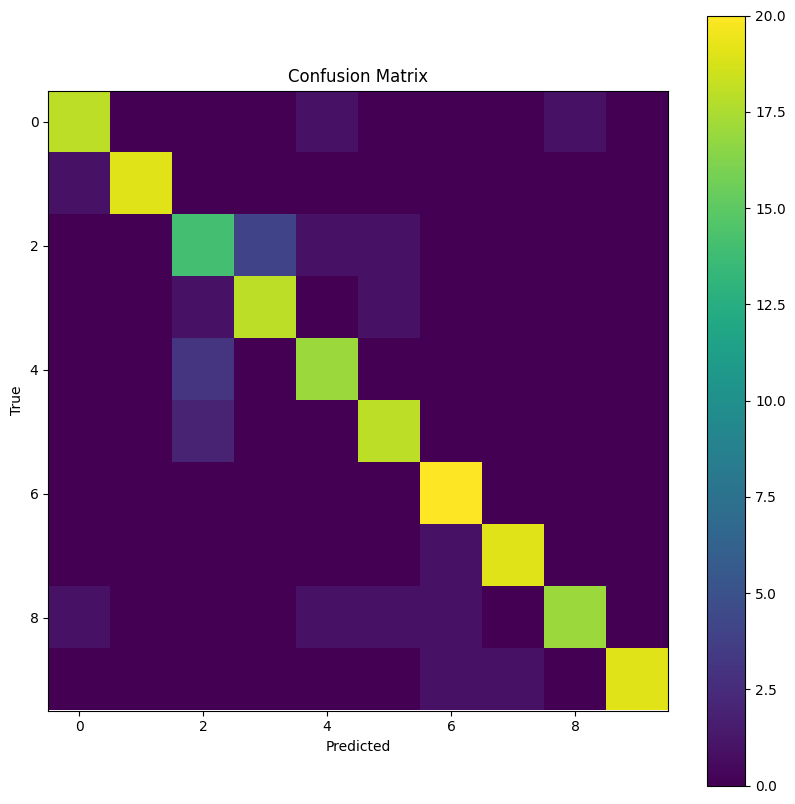

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(10,10))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("True")

plt.colorbar()

plt.show()

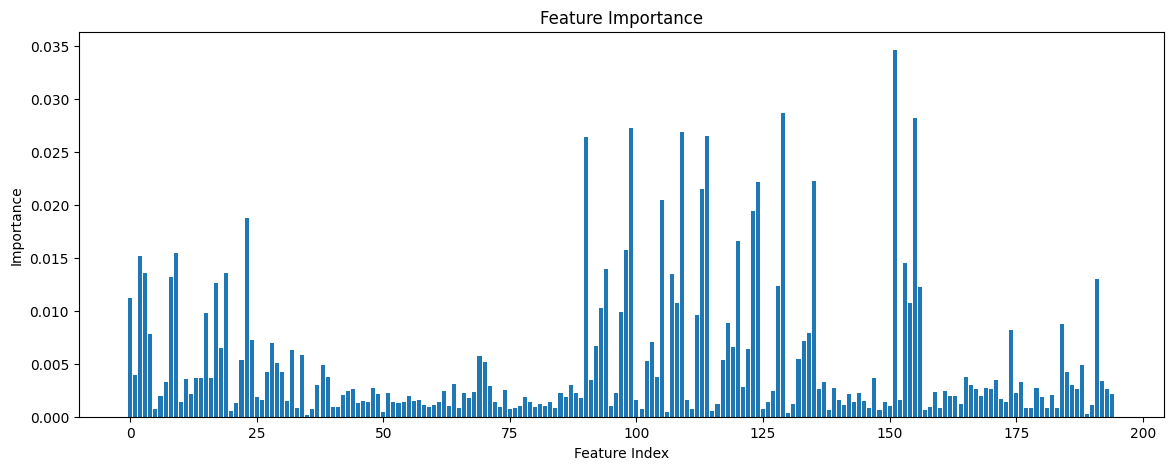

In [ ]:
importance = rf_model.feature_importances_

plt.figure(figsize=(14,5))

plt.bar(
    range(len(importance)),
    importance
)

plt.title("Feature Importance")

plt.xlabel("Feature Index")

plt.ylabel("Importance")

plt.show()

In [ ]:
joblib.dump(
    rf_model,
    "rf_model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Saved model and scaler.")

Saved model and scaler.


In [ ]:
files.download("rf_model.pkl")

files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

size_mb = os.path.getsize("rf_model.pkl") / (1024 * 1024)

print("Model size:", size_mb, "MB")

Model size: 0.9637384414672852 MB


In [ ]:
!pip install micromlgen

In [ ]:
from micromlgen import port

with open("rf_model.h", "w") as f:
    f.write(port(rf_model))

print("Exported rf_model.h")

Exported rf_model.h


In [ ]:
from google.colab import files

files.download("rf_model.h")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def to_cpp_array(arr, name):

    s = f"float {name}[{len(arr)}] = {{\n"

    for v in arr:
        s += f"{v}f,\n"

    s += "};"

    return s

means_cpp = to_cpp_array(means, "feature_means")

scales_cpp = to_cpp_array(scales, "feature_scales")

with open("scaler_params.h", "w") as f:

    f.write(means_cpp)
    f.write("\n\n")
    f.write(scales_cpp)

print("Saved scaler_params.h")

Saved scaler_params.h


In [ ]:
files.download("scaler_params.h")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
feature_names = []

def extract_features(data):

    global feature_names

    feature_names = []

    features = []

    axis_names = [
        "ax","ay","az",
        "gx","gy","gz",
        "mx","my","mz"
    ]

    for i in range(data.shape[1]):

        signal = data[:, i]

        axis = axis_names[i]

        # Basic stats
        features.append(np.mean(signal))
        feature_names.append(f"{axis}_mean")

        features.append(np.std(signal))
        feature_names.append(f"{axis}_std")

        features.append(np.min(signal))
        feature_names.append(f"{axis}_min")

        features.append(np.max(signal))
        feature_names.append(f"{axis}_max")

        features.append(np.median(signal))
        feature_names.append(f"{axis}_median")

        # Shape stats
        features.append(skew(signal))
        feature_names.append(f"{axis}_skew")

        features.append(kurtosis(signal))
        feature_names.append(f"{axis}_kurtosis")

        # Energy
        features.append(np.sum(signal ** 2))
        feature_names.append(f"{axis}_energy")

        # Percentiles
        features.append(np.percentile(signal, 25))
        feature_names.append(f"{axis}_p25")

        features.append(np.percentile(signal, 75))
        feature_names.append(f"{axis}_p75")

        # Signal dynamics
        diff_signal = np.diff(signal)

        features.append(np.mean(np.abs(diff_signal)))
        feature_names.append(f"{axis}_diff_mean")

        features.append(np.std(diff_signal))
        feature_names.append(f"{axis}_diff_std")

        # FFT features
        fft_vals = np.abs(np.fft.rfft(signal))

        features.append(np.mean(fft_vals))
        feature_names.append(f"{axis}_fft_mean")

        features.append(np.std(fft_vals))
        feature_names.append(f"{axis}_fft_std")

        features.append(np.max(fft_vals))
        feature_names.append(f"{axis}_fft_max")

    # Magnitudes
    acc_mag = np.linalg.norm(data[:, 0:3], axis=1)
    gyro_mag = np.linalg.norm(data[:, 3:6], axis=1)
    mag_mag = np.linalg.norm(data[:, 6:9], axis=1)

    mag_names = ["acc_mag", "gyro_mag", "mag_mag"]

    for idx, signal in enumerate([acc_mag, gyro_mag, mag_mag]):

        name = mag_names[idx]

        features.append(np.mean(signal))
        feature_names.append(f"{name}_mean")

        features.append(np.std(signal))
        feature_names.append(f"{name}_std")

        features.append(np.min(signal))
        feature_names.append(f"{name}_min")

        features.append(np.max(signal))
        feature_names.append(f"{name}_max")

        features.append(np.median(signal))
        feature_names.append(f"{name}_median")

        features.append(np.sum(signal ** 2))
        feature_names.append(f"{name}_energy")

        features.append(skew(signal))
        feature_names.append(f"{name}_skew")

        features.append(kurtosis(signal))
        feature_names.append(f"{name}_kurtosis")

    # Correlation features
    corr_matrix = np.corrcoef(data.T)

    upper = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]

    for idx in range(len(upper)):

        feature_names.append(f"corr_{idx}")

    features.extend(upper)

    return np.array(features)

In [ ]:
dummy = extract_features(np.random.randn(100,9))

for i, name in enumerate(feature_names):

    print(i, name)

0 ax_mean
1 ax_std
2 ax_min
3 ax_max
4 ax_median
5 ax_skew
6 ax_kurtosis
7 ax_energy
8 ax_p25
9 ax_p75
10 ax_diff_mean
11 ax_diff_std
12 ax_fft_mean
13 ax_fft_std
14 ax_fft_max
15 ay_mean
16 ay_std
17 ay_min
18 ay_max
19 ay_median
20 ay_skew
21 ay_kurtosis
22 ay_energy
23 ay_p25
24 ay_p75
25 ay_diff_mean
26 ay_diff_std
27 ay_fft_mean
28 ay_fft_std
29 ay_fft_max
30 az_mean
31 az_std
32 az_min
33 az_max
34 az_median
35 az_skew
36 az_kurtosis
37 az_energy
38 az_p25
39 az_p75
40 az_diff_mean
41 az_diff_std
42 az_fft_mean
43 az_fft_std
44 az_fft_max
45 gx_mean
46 gx_std
47 gx_min
48 gx_max
49 gx_median
50 gx_skew
51 gx_kurtosis
52 gx_energy
53 gx_p25
54 gx_p75
55 gx_diff_mean
56 gx_diff_std
57 gx_fft_mean
58 gx_fft_std
59 gx_fft_max
60 gy_mean
61 gy_std
62 gy_min
63 gy_max
64 gy_median
65 gy_skew
66 gy_kurtosis
67 gy_energy
68 gy_p25
69 gy_p75
70 gy_diff_mean
71 gy_diff_std
72 gy_fft_mean
73 gy_fft_std
74 gy_fft_max
75 gz_mean
76 gz_std
77 gz_min
78 gz_max
79 gz_median
80 gz_skew
81 gz_kurt